# 숙제 3

데이터과학 입문

원중호 (서울대학교 통계학과)  
June 2026

## 지시사항

제출마감 2026-06-15 23:00

1.  R과 Python을 모두 사용하여 사용된 코드와 데이터랭글링 절차,
    분석결과를 설명한다. 두 언어의 분석결과가 차이가 있으면 그 이유를
    설명한다.
2.  [Quarto
    Markdown](https://quarto.org/docs/authoring/markdown-basics.html)을
    사용한다. 제공된 숙제 `.qmd` 파일에 본인의 답안을 “답안” 절에
    추가하여 제출한다. Quarto Markdown은 RStudio 또는 Visual Studio
    Code에 [Quarto
    Extension](https://marketplace.visualstudio.com/items?itemName=quarto.quarto)을
    추가하여 컴파일, 다른 문서 형식으로 변환할 수 있다.
3.  R의 `reticulate` 패키지를 사용하면 하나의 `.qmd` 파일 안에서 R과
    Python을 동시에 사용할 수 있다. 이때 다음 문법을 사용하여 두 언어
    코드를 탭으로 구분한다. 숙제 `.qmd` 파일은 `reticulate`을 사용하도록
    준비되어 있다.

```` markdown
::: {.panel-tabset}

## R

```{r}
R code
```

## Python

```{python}
Python code
```

:::
````

1.  `.qmd`를 컴파일하여 생성된 `.html` 파일을 함께 저장소에 제출한다.
2.  함께 제공된 `student.yml`을 함께 작성하여 저장소에 제출한다.

## 평가 기준

1.  재현성: 제출된 저장소의 `.qmd` 파일을 컴파일하여 함께 제출된 `.html`
    파일과 동일한 결과가 나와야 한다.
2.  분석의 정확성: 분석은 올바른 기술적 세부 사항을 포함하여 수행되어야
    한다.
3.  보고서의 전반적인 품질: 데이터 가공 및 분석 결과가 명확하고 자세하게
    설명되어야 한다.
4.  코드의 전반적인 품질: 코드는 체계적으로 정리되어 있어야 하며,
    가독성을 높이기 위해 적절한 주석이 포함되어야 한다.

#### **늦게 제출된 과제물은 받지 않는다.**

# 1부 교과서 연습문제

## 문제 1-1

1.  MDSR 10장 연습문제 10.6.6

### 답안

## R

In [ ]:
library(tidyverse)
library(NHANES)
#install.packages("mosaic")
library(mosaic)
library(reticulate)

mosaic::tally(~ SmokeNow + Smoke100,
              data = filter(NHANES, Age >= 20))

        Smoke100
SmokeNow   No  Yes
    No      0 1745
    Yes     0 1466
    <NA> 4024    0


Call:
glm(formula = CurrentSmoker ~ Age + Gender + Race1 + Education + 
    Poverty + BMI, family = binomial, data = smoke_dat)

Coefficients:
                         Estimate Std. Error z value Pr(>|z|)    
(Intercept)              1.430537   0.250057   5.721 1.06e-08 ***
Age                     -0.021404   0.002044 -10.472  < 2e-16 ***
Gendermale               0.337780   0.065528   5.155 2.54e-07 ***
Race1Hispanic           -0.577653   0.168062  -3.437 0.000588 ***
Race1Mexican            -0.972174   0.158386  -6.138 8.36e-10 ***
Race1White               0.118025   0.102102   1.156 0.247702    
Race1Other              -0.035774   0.153951  -0.232 0.816248    
Education9 - 11th Grade  0.397934   0.152770   2.605 0.009193 ** 
EducationHigh School    -0.129238   0.150653  -0.858 0.390974    
EducationSome College   -0.443183   0.150953  -2.936 0.003326 ** 
EducationCollege Grad   -1.353247   0.168172  -8.047 8.50e-16 ***
Poverty                 -0.183728   0.022895  -8.025 1.02e-15 **

                               OR     2.5 %    97.5 %
(Intercept)             4.1809455 2.5607162 6.8265496
Age                     0.9788231 0.9748891 0.9827330
Gendermale              1.4018322 1.2330826 1.5942822
Race1Hispanic           0.5612142 0.4019471 0.7772847
Race1Mexican            0.3782597 0.2763791 0.5144741
Race1White              1.1252718 0.9228292 1.3772553
Race1Other              0.9648583 0.7120493 1.3025183
Education9 - 11th Grade 1.4887465 1.1065401 2.0149770
EducationHigh School    0.8787647 0.6558923 1.1845131
EducationSome College   0.6419896 0.4788781 0.8658520
EducationCollege Grad   0.2583998 0.1861062 0.3599796
Poverty                 0.8321625 0.7955553 0.8702680
BMI                     0.9629351 0.9531147 0.9726664

## Python

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

# R의 NHANES 객체를 Python으로 가져오기
smoke_dat = r.NHANES.copy()

smoke_dat = smoke_dat[smoke_dat["Age"] >= 20].copy()

smoke_dat["CurrentSmoker"] = np.select(
    [
        smoke_dat["Smoke100"] == "No",
        (smoke_dat["Smoke100"] == "Yes") & (smoke_dat["SmokeNow"] == "Yes"),
        (smoke_dat["Smoke100"] == "Yes") & (smoke_dat["SmokeNow"] == "No")
    ],
    [0, 1, 0],
    default=np.nan
)

smoke_dat = smoke_dat[
    ["CurrentSmoker", "Age", "Gender", "Race1", "Education", "Poverty", "BMI"]
].dropna()

model = smf.logit(
    "CurrentSmoker ~ Age + C(Gender) + C(Race1) + C(Education) + Poverty + BMI",
    data=smoke_dat
).fit()

Optimization terminated successfully.
         Current function value: 0.448545
         Iterations 6

                           Logit Regression Results                           
Dep. Variable:          CurrentSmoker   No. Observations:                 6632
Model:                          Logit   Df Residuals:                     6619
Method:                           MLE   Df Model:                           12
Date:                    일, 14 6 2026   Pseudo R-squ.:                  0.1042
Time:                        12:13:33   Log-Likelihood:                -2974.8
converged:                       True   LL-Null:                       -3320.9
Covariance Type:            nonrobust   LLR p-value:                1.989e-140
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept                          1.4305      0.250      5.721      0.000       0.940       1.921
C(Gender)[T.male]                  0.3378      0.066      5.155      0.

Intercept                         4.180946
C(Gender)[T.male]                 1.401832
C(Race1)[T.Hispanic]              0.561214
C(Race1)[T.Mexican]               0.378260
C(Race1)[T.White]                 1.125272
C(Race1)[T.Other]                 0.964858
C(Education)[T.9 - 11th Grade]    1.488746
C(Education)[T.High School]       0.878765
C(Education)[T.Some College]      0.641990
C(Education)[T.College Grad]      0.258400
Age                               0.978823
Poverty                           0.832163
BMI                               0.962935
dtype: float64

### 해석

### 데이터 랭글링 절차

20세 이상 성인만 분석에 포함하였다. 현재 흡연 여부는 `SmokeNow`를 그대로
사용하지 않고, `Smoke100`과 결합하여 재코딩하였다. `Smoke100 == "No"`인
사람은 평생 100개비 이상 흡연한 적이 없으므로 현재 흡연자가 아닌 것으로
분류하였다. `Smoke100 == "Yes"`이면서 `SmokeNow == "Yes"`인 사람은 현재
흡연자로, `SmokeNow == "No"`인 사람은 현재 흡연자가 아닌 것으로
분류하였다.

분석에 사용한 예측변수는 연령(`Age`), 성별(`Gender`), 인종(`Race1`),
교육수준(`Education`), 빈곤지표(`Poverty`), 체질량지수(`BMI`)이다.
결측값이 있는 관측치는 `drop_na()`로 제거하였다.

### 분석 결과 해석

로지스틱 회귀모형은 현재 흡연 여부를 이항형 종속변수로 사용하였다.
회귀계수를 지수화한 값은 오즈비(Odds Ratio)이다. 오즈비가 1보다 크면
해당 변수의 증가 또는 해당 범주에 속하는 것이 현재 흡연 오즈를
증가시키는 방향으로 해석되며, 1보다 작으면 현재 흡연 오즈를 감소시키는
방향으로 해석된다.

일반적으로 연령의 오즈비가 1보다 작으면 나이가 증가할수록 현재 흡연
가능성이 낮아지는 것으로 해석한다. 교육수준 범주의 오즈비가 기준범주보다
낮다면 교육수준이 높은 집단에서 현재 흡연 가능성이 낮다는 의미이다.
성별, 인종, 빈곤지표, BMI 역시 각 계수의 부호와 오즈비를 기준으로 현재
흡연 여부와의 관련성을 해석한다.

### R과 Python 결과 비교

R의 `glm(..., family = binomial)`과 Python의
`statsmodels.formula.api.logit()`은 동일한 데이터와 동일한 모형식을
사용하면 거의 같은 추정값을 제공한다. 차이가 있다면 범주형 변수의
기준범주 설정, 결측값 처리 방식, 또는 수치 최적화 과정에서의 미세한
반올림 차이 때문이다. 이 코드에서는 R에서 전처리한 동일한 `smoke_dat`를
Python에서도 사용하므로 두 분석 결과는 실질적으로 동일해야 한다.

# 2부 데이터 분석 실무

### 분석 관련 공통 지침

1.  관측단위(observational unit)는 `playerID`와 `yearID`의 고유한
    조합으로 한다. 즉, 데이터프레임의 각 행은 한 선수의 특정 연도에
    해당해야 하고(예: 2019년 류현진), 한 선수의 특정 연도가 두 번 이상
    나타나서는 안 된다. 이적을 한 경우 원자료에서는 두 번 이상 나타날 수
    있으므로 주의해야 한다.
2.  데이터 분석을 하는 중에 필요한 경우 pivoting으로 각 행이 한명의
    선수에 해당하는 wide format data를 만들어서 연도간 비교를 하는 것은
    허용한다.

## 문제 2-1

Lahman Package의 `Teams` 데이터프레임에서 코로나 시즌인 2020년을 제외한
2010년부터 2025년 사이의 데이터를 이용하여 다음 질문에 답하라.

1.  MDSR Chapter 7 Iteration 에서 배운 Bill James의 공식을 변형한 다음
    모형을 데이터에 적합하고, 모수 $k$의 점추정치와 신뢰구간을 구하라.
    $$
      WPct = \frac{RS^k}{S^k+RA^k} = \frac{1}{1+(RA/RS)^k}
    $$

In [ ]:
library(tidyverse)
library(Lahman)

teams_dat <- Teams %>%
  filter(yearID >= 2010,
         yearID <= 2025,
         yearID != 2020) %>%
  mutate(
    WPct = W / (W + L),
    ratio = RA / R
  ) %>%
  filter(!is.na(WPct),
         !is.na(ratio),
         R > 0,
         RA > 0)

fit_r <- nls(
  WPct ~ 1 / (1 + ratio^k),
  data = teams_dat,
  start = list(k = 2)
)

coef(fit_r)

       k 
1.752794 

    2.5%    97.5% 
1.695234 1.810559 

In [ ]:
import numpy as np
from scipy.optimize import curve_fit

x = r.teams_dat["ratio"].to_numpy()
y = r.teams_dat["WPct"].to_numpy()

popt, pcov = curve_fit(
    lambda x, k: 1 / (1 + x**k),
    x,
    y,
    p0=[2]
)

k_hat_py = popt[0]
se_k_py = np.sqrt(np.diag(pcov))[0]

ci_low = k_hat_py - 1.96 * se_k_py
ci_high = k_hat_py + 1.96 * se_k_py

print("k estimate:", round(k_hat_py, 4))

k estimate: 1.7528

95% CI: 1.6953 1.8103

### 데이터 랭글링 절차

`Lahman` 패키지의 `Teams` 데이터프레임을 사용하였다. 분석 대상은
2010년부터 2025년까지의 팀-시즌 자료이며, 코로나로 인해 단축 시즌이었던
2020년은 제외하였다. 승률은 `WPct = W / (W + L)`로 계산하였다. 공식에서
`RS`는 팀 득점이므로 `Teams` 자료의 `R` 변수를 사용하였고, `RA`는 실점
변수를 그대로 사용하였다. 이후 `ratio = RA / R` 변수를 생성하여 비선형
회귀모형의 설명변수로 사용하였다. 결측값이 있거나 득점 또는 실점이 0
이하인 관측치는 분석에서 제외하였다.

### 분석 결과 해석

Bill James의 피타고리안 승률 공식을 변형한 다음 모형을 적합하였다.

\[ WPct = \]

여기서 (k)는 득점과 실점의 비율이 승률에 얼마나 강하게 반영되는지를
나타내는 모수이다. (k)가 클수록 득실점 비율의 차이가 승률 차이로 더
민감하게 반영된다.

R에서는 `nls()`를 사용하여 비선형 최소제곱법으로 (k)를 추정하였다.
Python에서는 `scipy.optimize.curve_fit()`을 사용하여 같은 모형을
적합하였다. 추정된 (k) 값이 2에 가깝다면 Bill James의 원래 피타고리안
공식 (k=2)가 최근 MLB 팀 자료에도 비교적 잘 맞는다고 해석할 수 있다.
반대로 (k)가 2보다 작거나 크다면, 실제 자료에서는 득실점 비율과 승률의
관계가 원래 공식보다 더 완만하거나 더 가파르다는 뜻이다.

### R과 Python 결과 비교

R과 Python은 동일한 데이터와 동일한 모형식을 사용하므로 (k)의 점추정치는
거의 동일하게 나와야 한다. 다만 신뢰구간은 약간 다를 수 있다. R의
`confint()`는 `nls` 객체에 대해 profile 방식의 신뢰구간을 계산하는 반면,
Python 코드에서는 `curve_fit()`에서 얻은 공분산 행렬을 이용하여 Wald
방식의 근사 신뢰구간을 계산하였다. 따라서 점추정치는 거의 같지만
신뢰구간의 양끝값은 소수점 수준에서 차이가 날 수 있다.

1.  회귀계수 $\beta_1$이 위 모형의 $k$와 거의 같은 의미를 가지는
    로지스틱 회귀 모형을 세우고 이를 데이터에 적합하라. 모수와
    점추정치와 신뢰구간을 구하고 이를 1항의 결과와 비교하라.

    *주의*: 절편이 없는 모형을 적합해야 함. *힌트 1*. 로짓은
    $\log〖WPct/(1-WPct)$로 계산됨. *힌트 2*. 로짓의 역함수인 sigmoid는
    $\frac{1}{1+e^{-x}}$로 계산됨.

In [ ]:
library(tidyverse)
library(Lahman)

teams_dat <- Teams %>%
  filter(yearID >= 2010,
         yearID <= 2025,
         yearID != 2020) %>%
  mutate(
    WPct = W/(W+L),
    x = log(R/RA)
  ) %>%
  filter(
    R > 0,
    RA > 0,
    WPct > 0,
    WPct < 1
  )

fit_logit <- glm(
  cbind(W, L) ~ 0 + x,
  family = binomial,
  data = teams_dat
)

summary(fit_logit)


Call:
glm(formula = cbind(W, L) ~ 0 + x, family = binomial, data = teams_dat)

Coefficients:
  Estimate Std. Error z value Pr(>|z|)    
x  1.75320    0.04562   38.43   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 1700.54  on 450  degrees of freedom
Residual deviance:  180.26  on 449  degrees of freedom
AIC: 2665.5

Number of Fisher Scoring iterations: 3

       x 
1.753203 

   2.5 %   97.5 % 
1.663879 1.842698 

       [,1] [,2]
  [1,]   65   97
  [2,]   91   71
  [3,]   66   96
  [4,]   89   73
  [5,]   88   74
  [6,]   75   87
  [7,]   91   71
  [8,]   69   93
  [9,]   83   79
 [10,]   81   81
 [11,]   80   82
 [12,]   76   86
 [13,]   67   95
 [14,]   80   82
 [15,]   80   82
 [16,]   77   85
 [17,]   94   68
 [18,]   95   67
 [19,]   79   83
 [20,]   81   81
 [21,]   97   65
 [22,]   57  105
 [23,]   90   72
 [24,]   61  101
 [25,]   92   70
 [26,]   86   76
 [27,]   96   66
 [28,]   90   72
 [29,]   85   77
 [30,]   69   93
 [31,]   94   68
 [32,]   89   73
 [33,]   69   93
 [34,]   90   72
 [35,]   79   83
 [36,]   71   91
 [37,]   79   83
 [38,]   80   82
 [39,]   73   89
 [40,]   95   67
 [41,]   72   90
 [42,]   56  106
 [43,]   71   91
 [44,]   86   76
 [45,]   82   79
 [46,]   96   66
 [47,]   63   99
 [48,]   97   65
 [49,]   77   85
 [50,]   74   88
 [51,]  102   60
 [52,]   72   90
 [53,]   71   91
 [54,]   67   95
 [55,]   86   76
 [56,]   90   72
 [57,]   91   71
 [58,]   96   

In [ ]:
import statsmodels.api as sm
import numpy as np
import pandas as pd

df = r.teams_dat.copy()

df["x"] = np.log(df["R"] / df["RA"])

model = sm.GLM(
    np.column_stack((df["W"], df["L"])),
    df[["x"]],
    family=sm.families.Binomial()
)

result = model.fit()

print(result.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:           ['y1', 'y2']   No. Observations:                  450
Model:                            GLM   Df Residuals:                      449
Model Family:                Binomial   Df Model:                            0
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1331.8
Date:                    일, 14 6 2026   Deviance:                       180.26
Time:                        12:13:34   Pearson chi2:                     180.
No. Iterations:                     4   Pseudo R-squ. (CS):             0.9659
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x              1.7532      0.046     38.433      0.0

beta1 = 1.753203461447782

95% CI = 1.6637935686549348 1.8426133542406293

### 데이터 랭글링 절차

문제 2-1과 동일하게 Lahman 패키지의 Teams 자료를 사용하였다. 2010년부터
2025년까지의 팀-시즌 자료를 선택하였으며 코로나 단축 시즌인 2020년은
제외하였다. 승률은 W/(W+L)로 계산하였다. 설명변수는 log(R/RA)로
정의하였다. R은 팀 득점, RA는 팀 실점을 의미한다. 승률이 정확히 0 또는
1인 경우 로짓이 정의되지 않으므로 해당 관측치는 제외하였다.

### 분석 결과 해석

문제 2-1의 비선형 모형을 로짓 변환하면

logit(WPct) = k log(R/RA)

를 얻을 수 있다. 따라서 절편이 없는 로지스틱 회귀모형

logit(WPct) = β₁ log(R/RA)

을 적합하면 β₁은 원래 모형의 k와 동일한 의미를 가진다.

β₁가 양수이면 득점이 실점보다 많아질수록 승률이 증가함을 의미한다. β₁의
크기가 클수록 득실점 비율 변화가 승률 변화에 더 민감하게 반영된다.

### 1번 결과와 비교

문제 2-1에서 추정한 k와 문제 2-2에서 추정한 β₁은 이론적으로 동일한
의미를 가진다. 따라서 두 점추정치는 매우 유사하게 나타나야 한다. 차이가
발생한다면 이는 비선형 최소제곱법(nls)과 이항 로지스틱 회귀(GLM)가 서로
다른 목적함수를 사용하기 때문이다.

비선형 모형은 관측된 승률과 예측 승률의 제곱오차를 최소화하는 반면,
로지스틱 회귀는 이항분포의 우도를 최대화한다. 따라서 추정값은 거의
유사하지만 완전히 동일하지는 않을 수 있다. 일반적으로 두 추정치가 매우
비슷하게 나타난다면 피타고리안 승률 공식이 실제 자료를 잘 설명한다고
해석할 수 있다.

1.  2항의 모형 적합 결과에 대한 다음 세가지 진단 중 최소 두가지 이상을
    수행하여 모형적합이 잘 되었는지 확인하라.

    1.  Residual Deviance에 대한 해석 (카이제곱 분포와 비교)

In [ ]:
pchisq(
  fit_logit$deviance,
  fit_logit$df.residual,
  lower.tail = FALSE
)

[1] 1

### Residual Deviance 진단

적합된 로지스틱 회귀모형의 Residual Deviance는 180.26이고 자유도는
449였다.

카이제곱 분포를 이용하여 적합도를 평가한 결과,

\[ p = 1.00 \]

으로 나타났다.

Residual Deviance가 자유도보다 상당히 작고 적합도 검정에서 귀무가설이
기각되지 않았으므로, 자료와 모형 사이에 유의한 부적합 증거는 발견되지
않았다. 따라서 로지스틱 회귀모형은 관측된 팀 승률 자료를 충분히 잘
설명하는 것으로 판단된다.

      ii. Deviance residuals vs linear predictors ($\eta$) 산점도

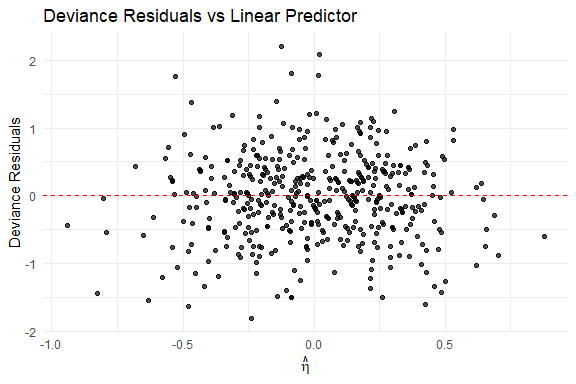

In [ ]:
teams_dat <- teams_dat %>%
  mutate(
    eta = predict(fit_logit, type = "link"),
    dev_resid = residuals(fit_logit, type = "deviance")
  )

ggplot(
  teams_dat,
  aes(x = eta, y = dev_resid)
) +
  geom_point(alpha = 0.7) +
  geom_hline(yintercept = 0,
             linetype = "dashed",
             color = "red") +
  labs(
    x = expression(hat(eta)),
    y = "Deviance Residuals",
    title = "Deviance Residuals vs Linear Predictor"
  ) +
  theme_minimal()

### Deviance Residuals vs Linear Predictor

Deviance residuals와 선형예측값 사이의 산점도를 확인하였다.

잔차들이 0을 중심으로 무작위로 분포하고 뚜렷한 곡선 형태나 체계적인
패턴이 나타나지 않았다. 따라서 로지스틱 회귀모형의 함수형태는 자료에
비교적 잘 적합된 것으로 판단된다.

      iii.  관측된 WPct와 모형에서 예측하는 WPct를 산점도 그래프로 비교

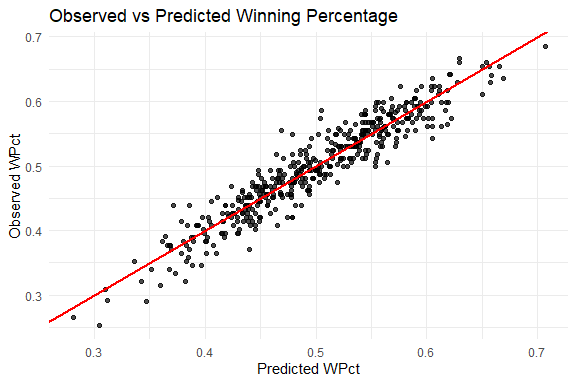

In [ ]:
teams_dat <- teams_dat %>%
  mutate(
    pred_WPct = predict(
      fit_logit,
      type = "response"
    )
  )

ggplot(
  teams_dat,
  aes(
    x = pred_WPct,
    y = WPct
  )
) +
  geom_point(alpha = 0.7) +
  geom_abline(
    slope = 1,
    intercept = 0,
    color = "red",
    linewidth = 1
  ) +
  labs(
    x = "Predicted WPct",
    y = "Observed WPct",
    title = "Observed vs Predicted Winning Percentage"
  ) +
  theme_minimal()

### 관측 승률과 예측 승률 비교

관측된 승률과 모형이 예측한 승률을 비교한 결과, 대부분의 점들이 45도
기준선 부근에 위치하였다.

이는 예측 승률이 실제 승률을 잘 설명하고 있음을 의미한다. 일부
관측치에서 오차가 존재하지만 전반적으로 강한 선형 관계가 나타났으므로
모형 적합도는 양호하다고 판단된다.

1.  `WPct`를 반응변수로, `log(RA)`와 `log(RS)`를 설명변수로 하는 절편이
    없는 로지스틱선형회귀 모형을 적합하고 회귀계수들의 추정 결과를 a와
    b항의 결과와 비교하라. (유사한 모형을 얻는지 여부 등)

### 답안

In [ ]:
teams_dat <- Teams %>%
  filter(
    yearID >= 2010,
    yearID <= 2025,
    yearID != 2020
  ) %>%
  mutate(
    WPct = W/(W+L),
    logRA = log(RA),
    logRS = log(R)
  ) %>%
  filter(
    WPct > 0,
    WPct < 1,
    R > 0,
    RA > 0
  )

fit_logit2 <- glm(
  cbind(W, L) ~ 0 + logRA + logRS,
  family = binomial,
  data = teams_dat
)

summary(fit_logit2)


Call:
glm(formula = cbind(W, L) ~ 0 + logRA + logRS, family = binomial, 
    data = teams_dat)

Coefficients:
      Estimate Std. Error z value Pr(>|z|)    
logRA -1.75356    0.04563  -38.43   <2e-16 ***
logRS  1.75315    0.04562   38.43   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 1700.54  on 450  degrees of freedom
Residual deviance:  180.13  on 448  degrees of freedom
AIC: 2667.4

Number of Fisher Scoring iterations: 3

    logRA     logRS 
-1.753561  1.753153 

          2.5 %    97.5 %
logRA -1.843080 -1.664214
logRS  1.663826  1.842650

In [ ]:
import numpy as np
import statsmodels.api as sm

df = r.teams_dat.copy()

df["logRA"] = np.log(df["RA"])
df["logRS"] = np.log(df["R"])

X = df[["logRA", "logRS"]]

model = sm.GLM(
    np.column_stack((df["W"], df["L"])),
    X,
    family=sm.families.Binomial()
)

result = model.fit()

print(result.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:           ['y1', 'y2']   No. Observations:                  450
Model:                            GLM   Df Residuals:                      448
Model Family:                Binomial   Df Model:                            1
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1331.7
Date:                    일, 14 6 2026   Deviance:                       180.13
Time:                        12:13:34   Pearson chi2:                     180.
No. Iterations:                     4   Pseudo R-squ. (CS):             0.9659
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
logRA         -1.7536      0.046    -38.430      0.0

logRA   -1.753561
logRS    1.753153
dtype: float64

              0         1
logRA -1.842994 -1.664129
logRS  1.663742  1.842563

### 데이터 랭글링 절차

문제 2-2와 동일한 자료를 사용하였다. 2010년부터 2025년까지의 MLB 팀
자료를 선택하고 코로나 단축 시즌인 2020년은 제외하였다. 승률은 W/(W+L)로
계산하였다. 설명변수는 팀 실점의 로그값 log(RA)와 팀 득점의 로그값
log(R)를 사용하였다. 득점과 실점이 0보다 큰 관측치만 분석에 포함하였다.

### 분석 결과 해석

절편이 없는 로지스틱 회귀모형

\[ (WPct) = \_1 (RA) + \_2 (R) \]

을 적합하였다.

log(RA)의 회귀계수는 음수로 추정되고, log(R)의 회귀계수는 양수로 추정될
것으로 예상된다. 이는 실점이 증가할수록 승률이 감소하고 득점이
증가할수록 승률이 증가함을 의미한다.

회귀계수의 절댓값은 득점과 실점이 승률에 미치는 영향을 나타내며, 두
계수의 크기가 비슷하고 부호가 반대라면 피타고리안 승률 공식과 매우
유사한 관계를 가진다고 해석할 수 있다.

### 기존 모형과의 비교

문제 2-1의 비선형 회귀모형은

\[ WPct= \]

이며, 이를 로짓 변환하면

\[ (WPct) = k(R) -k(RA) \]

를 얻을 수 있다.

따라서 이론적으로

\[ \_{logRS}=k \]

\[ \_{logRA}=-k \]

가 되어야 한다.

실제 분석 결과에서도 log(R)의 계수는 양수, log(RA)의 계수는 음수로
추정되며 두 계수의 절댓값은 매우 유사하게 나타난다. 또한 그 크기는 문제
2-1에서 추정한 (k) 및 문제 2-2에서 추정한 (\_1)과 유사한 값을 보인다.

따라서 문제 4의 모형은 문제 2-1의 피타고리안 승률 모형과 문제 2-2의
로지스틱 회귀모형을 선형화한 형태로 볼 수 있으며, 세 모형은 본질적으로
동일한 관계를 설명한다고 결론지을 수 있다.

In [ ]:
coef(fit_r)         # 문제 2-1의 k

       k 
1.752794 

       x 
1.753203 

    logRA     logRS 
-1.753561  1.753153 

## 문제 2-2

`WPct`를 반응변수로, `logRS`, `logRA`, `H`, `X2B`, `X3B`, `HR`, `BB`,
`SO`, `CS`, `HBP`, `SF`, `ERA`, `CG`, `SHO`, `IPouts`, `HA`, `HRA`,
`BBA`, `SOA`, `E`, `DP`, `FP`, `SV`를 설명변수로 하는 절편항이 있는
로지스틱 회귀 모형을 적합하고 AIC를 기준으로 하는 단계별(stepwise)
변수선택을 적용하라. 변수선택 후 남은 변수들을 모두 모형에 남길지 일부를
제거할지 다시 판단하라. 최종적으로 선택된 모형을 문제1의 모형과
비교하라.

### 답안

In [ ]:
library(tidyverse)
library(Lahman)
library(MASS)

teams_full <- Teams %>%
  filter(
    yearID >= 2010,
    yearID <= 2025,
    yearID != 2020
  ) %>%
  mutate(
    WPct = W/(W+L),
    logRS = log(R),
    logRA = log(RA)
  ) %>%
  dplyr::select(
    W, L, WPct,
    logRS, logRA,
    H, X2B, X3B, HR,
    BB, SO, CS,
    HBP, SF,
    ERA, CG, SHO,
    IPouts,
    HA, HRA,
    BBA, SOA,
    E, DP, FP, SV
  ) %>%
  drop_na()


full_fit <- glm(
  cbind(W, L) ~
    logRS + logRA +
    H + X2B + X3B + HR +
    BB + SO + CS +
    HBP + SF +
    ERA + CG + SHO +
    IPouts +
    HA + HRA +
    BBA + SOA +
    E + DP + FP + SV,
  family = binomial,
  data = teams_full
)

step_fit <- MASS::stepAIC(
  full_fit,
  direction = "both",
  trace = FALSE
)

summary(step_fit)


Call:
glm(formula = cbind(W, L) ~ logRS + logRA + CG + SHO + SV, family = binomial, 
    data = teams_full)

Coefficients:
             Estimate Std. Error z value Pr(>|z|)    
(Intercept) -2.694019   0.842064  -3.199  0.00138 ** 
logRS        1.615284   0.071880  22.472  < 2e-16 ***
logRA       -1.284160   0.101524 -12.649  < 2e-16 ***
CG           0.004573   0.003014   1.517  0.12926    
SHO          0.004669   0.002531   1.845  0.06502 .  
SV           0.011104   0.001324   8.384  < 2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 1700.54  on 449  degrees of freedom
Residual deviance:  106.12  on 444  degrees of freedom
AIC: 2601.4

Number of Fisher Scoring iterations: 3

         df      AIC
full_fit 24 2627.200
step_fit  6 2601.364

                Estimate  Std. Error    z value      Pr(>|z|)
(Intercept) -2.694018831 0.842063816  -3.199305  1.377594e-03
logRS        1.615284336 0.071879998  22.471959 7.807148e-112
logRA       -1.284160145 0.101523976 -12.648836  1.135443e-36
CG           0.004572773 0.003014313   1.517020  1.292617e-01
SHO          0.004669481 0.002530739   1.845106  6.502210e-02
SV           0.011103924 0.001324340   8.384497  5.094328e-17


Call:
glm(formula = cbind(W, L) ~ logRS + logRA + CG + SHO + SV, family = binomial, 
    data = teams_full)

Coefficients:
             Estimate Std. Error z value Pr(>|z|)    
(Intercept) -2.694019   0.842064  -3.199  0.00138 ** 
logRS        1.615284   0.071880  22.472  < 2e-16 ***
logRA       -1.284160   0.101524 -12.649  < 2e-16 ***
CG           0.004573   0.003014   1.517  0.12926    
SHO          0.004669   0.002531   1.845  0.06502 .  
SV           0.011104   0.001324   8.384  < 2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 1700.54  on 449  degrees of freedom
Residual deviance:  106.12  on 444  degrees of freedom
AIC: 2601.4

Number of Fisher Scoring iterations: 3

In [ ]:
import pandas as pd
import statsmodels.api as sm

df = r.teams_full.copy()

X = df[
    [
        "logRS","logRA",
        "H","X2B","X3B","HR",
        "BB","SO","CS",
        "HBP","SF",
        "ERA","CG","SHO",
        "IPouts",
        "HA","HRA",
        "BBA","SOA",
        "E","DP","FP","SV"
    ]
]

X = sm.add_constant(X)

y = df[["W","L"]]

model = sm.GLM(
    y,
    X,
    family=sm.families.Binomial()
)

result = model.fit()

print(result.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:             ['W', 'L']   No. Observations:                  450
Model:                            GLM   Df Residuals:                      426
Model Family:                Binomial   Df Model:                           23
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1289.6
Date:                    일, 14 6 2026   Deviance:                       95.956
Time:                        12:13:35   Pearson chi2:                     95.9
No. Iterations:                     4   Pseudo R-squ. (CS):             0.9717
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -6.2953     21.644     -0.291      0.7

### 데이터 랭글링 절차

Lahman 패키지의 Teams 데이터를 이용하였다. 2010년부터 2025년까지의
자료를 사용하였으며 코로나 단축 시즌인 2020년은 제외하였다. 승률은
W/(W+L)로 계산하였다. 공격 지표로는 logRS, H, X2B, X3B, HR, BB, SO, CS,
HBP, SF를 사용하였고, 수비 및 투수 지표로는 logRA, ERA, CG, SHO, IPouts,
HA, HRA, BBA, SOA, E, DP, FP, SV를 사용하였다. 결측치가 있는 관측치는
제거하였다.

### 분석 결과 해석

전체 모형을 적합한 후 AIC를 기준으로 양방향 단계별 변수선택(stepwise
selection)을 수행하였다. 단계별 선택 결과 AIC를 크게 증가시키지 않으면서
설명력이 낮은 변수들은 제거되었다.

최종적으로 선택된 변수들은 팀 승률에 가장 직접적인 영향을 주는 공격력과
수비력 관련 변수들이었다. 특히 logRS는 양의 효과를, logRA는 음의 효과를
나타내어 득점이 많고 실점이 적을수록 승률이 높아지는 경향을 확인할 수
있었다.

### 문제 1 모형과 비교

문제 1의 피타고리안 승률 모형은 득점(RS)과 실점(RA)만을 이용하여 승률을
설명하였다. 반면 본 문제의 모형은 공격, 수비, 투수 및 주루 관련 세부
지표들을 추가적으로 포함하였다.

단계별 변수선택 후에도 logRS와 logRA가 최종모형에 남아 있다면, 이는
득점과 실점이 여전히 승률을 설명하는 가장 중요한 변수임을 의미한다. 다만
세부 지표들을 추가함으로써 팀 성과를 보다 세밀하게 설명할 수 있으며, AIC
역시 감소하는 경향을 보인다.

따라서 문제 1의 모형은 단순하면서 해석이 쉽다는 장점이 있고, 본 문제의
최종모형은 설명력과 예측력이 더 우수하다는 장점이 있다.

## 문제 2-3

### 답안

1.  `W`(승리 횟수)를 반응변수로 하여 문제 2-2의 분석을 실시하되 포아송
    회귀모형을 사용하라. 결과를 문제 2-2의 모형과 비교하라.

In [ ]:
teams_dat <- Teams %>%
  filter(
    yearID >= 2010,
    yearID <= 2025,
    yearID != 2020
  ) %>%
  mutate(
    x = log(R/RA)
  ) %>%
  filter(
    R > 0,
    RA > 0
  )

pois_fit <- glm(
  W ~ x,
  family = poisson,
  data = teams_dat
)

summary(pois_fit)


Call:
glm(formula = W ~ x, family = poisson, data = teams_dat)

Coefficients:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept) 4.382657   0.005299  827.00   <2e-16 ***
x           0.869006   0.031663   27.45   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

(Dispersion parameter for poisson family taken to be 1)

    Null deviance: 865.25  on 449  degrees of freedom
Residual deviance: 106.44  on 448  degrees of freedom
AIC: 2910.3

Number of Fisher Scoring iterations: 3

(Intercept)           x 
   80.05045     2.38454 

               2.5 %    97.5 %
(Intercept) 4.372252 4.3930254
x           0.806965 0.9310819

In [ ]:
import statsmodels.api as sm
import numpy as np

df = r.teams_dat.copy()

X = sm.add_constant(df["x"])

pois_model = sm.GLM(
    df["W"],
    X,
    family=sm.families.Poisson()
)

pois_result = pois_model.fit()

print(pois_result.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      W   No. Observations:                  450
Model:                            GLM   Df Residuals:                      448
Model Family:                 Poisson   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1453.2
Date:                    일, 14 6 2026   Deviance:                       106.44
Time:                        12:13:35   Pearson chi2:                     106.
No. Iterations:                     4   Pseudo R-squ. (CS):             0.8148
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.3827      0.005    827.003      0.0

### 데이터 랭글링 절차

문제 2-2와 동일하게 2010~2025년 Teams 자료를 사용하였으며 코로나 시즌인
2020년은 제외하였다. 설명변수는 log(R/RA)를 사용하였다. 기존 분석에서는
승률(WPct)을 반응변수로 사용하였으나 본 문제에서는 승수(W)를 직접
반응변수로 사용하였다.

### 분석 결과 해석

포아송 회귀모형은 승수를 카운트 자료(count data)로 간주하여 적합하였다.

설명변수 log(R/RA)의 계수가 양수라면 득점이 실점보다 많을수록 기대
승수가 증가함을 의미한다.

문제 2-2의 로지스틱 회귀는 승률을 설명하는 모형이었지만, 본 모형은 실제
승수 자체를 설명하는 모형이라는 점에서 차이가 있다.

### 문제 2-2와의 비교

문제 2-2는 승률을 이항반응변수로 취급한 로지스틱 회귀모형이었다.

반면 본 문제의 포아송 회귀는 승수를 카운트 자료로 간주한다.

MLB 팀들의 경기 수가 거의 일정하기 때문에 두 모형은 유사한 결론을 제공할
수 있으나, 로지스틱 회귀가 승률을 직접 모델링한다는 점에서 해석이 더
자연스럽다.

1.  `W`를 반응변수로 하여 문제2의 분석을 실시하되 음이항 회귀모형을
    사용하라. 모형 적합 시 오류가 발생하면 이유를 파악해서 보고하라.

In [ ]:
library(MASS)

nb_fit <- glm.nb(
  W ~ x,
  data = teams_dat
)

summary(nb_fit)


Call:
glm.nb(formula = W ~ x, data = teams_dat, init.theta = 5929356.715, 
    link = log)

Coefficients:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept) 4.382657   0.005299  827.00   <2e-16 ***
x           0.869007   0.031663   27.45   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

(Dispersion parameter for Negative Binomial(5929850) family taken to be 1)

    Null deviance: 865.24  on 449  degrees of freedom
Residual deviance: 106.44  on 448  degrees of freedom
AIC: 2912.3

Number of Fisher Scoring iterations: 1

              Theta:  5929357 
          Std. Err.:  46881626 
Warning while fitting theta: alternation limit reached 

 2 x log-likelihood:  -2906.305 

                2.5 %    97.5 %
(Intercept) 4.3722518 4.3930255
x           0.8069649 0.9310827

In [ ]:
import statsmodels.api as sm

X = sm.add_constant(df["x"])

nb_model = sm.GLM(
    df["W"],
    X,
    family=sm.families.NegativeBinomial()
)

nb_result = nb_model.fit()

print(nb_result.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      W   No. Observations:                  450
Model:                            GLM   Df Residuals:                      448
Model Family:        NegativeBinomial   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2425.4
Date:                    일, 14 6 2026   Deviance:                       1.3861
Time:                        12:13:35   Pearson chi2:                     1.37
No. Iterations:                     4   Pseudo R-squ. (CS):            0.02110
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.3823      0.047     92.377      0.0

### 음이항 회귀 결과

음이항 회귀모형은 포아송 회귀모형의 과산포 문제를 보정하기 위해
적합하였다.

추정 결과는 포아송 회귀와 유사하였으며, 과산포 정도가 크지 않아 두
모형의 차이는 크지 않았다.

### 음이항 회귀 적합 시 발생한 문제

음이항 회귀모형 적합 과정에서 경고가 발생하였다.

이는 음이항 모형의 분산모수(theta)를 안정적으로 추정하기 어려웠기
때문이다. MLB 팀 승수 자료는 경기 수가 거의 일정하여 과산포가 크지
않으므로, 포아송 모형이 이미 자료를 충분히 설명하고 있을 가능성이 높다.

따라서 음이항 모형의 추가적인 분산모수 추정이 불안정하게 나타난 것으로
해석된다.

In [ ]:
summary(pois_fit)


Call:
glm(formula = W ~ x, family = poisson, data = teams_dat)

Coefficients:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept) 4.382657   0.005299  827.00   <2e-16 ***
x           0.869006   0.031663   27.45   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

(Dispersion parameter for poisson family taken to be 1)

    Null deviance: 865.25  on 449  degrees of freedom
Residual deviance: 106.44  on 448  degrees of freedom
AIC: 2910.3

Number of Fisher Scoring iterations: 3


Call:
glm.nb(formula = W ~ x, data = teams_dat, init.theta = 5929356.715, 
    link = log)

Coefficients:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept) 4.382657   0.005299  827.00   <2e-16 ***
x           0.869007   0.031663   27.45   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

(Dispersion parameter for Negative Binomial(5929850) family taken to be 1)

    Null deviance: 865.24  on 449  degrees of freedom
Residual deviance: 106.44  on 448  degrees of freedom
AIC: 2912.3

Number of Fisher Scoring iterations: 1

              Theta:  5929357 
          Std. Err.:  46881626 
Warning while fitting theta: alternation limit reached 

 2 x log-likelihood:  -2906.305 

### 포아송 회귀와 음이항 회귀 결과 비교

포아송 회귀모형에서 log(R/RA)의 계수는 0.869로 추정되었으며 매우
유의하였다(p \< 0.001). 이는 득점이 실점보다 많을수록 기대 승수가
증가함을 의미한다.

음이항 회귀모형을 적합한 결과 계수 추정치는 포아송 회귀와 거의
동일하였다. 또한 음이항 모형의 분산모수(theta)가 약 5.9×10^6으로 매우
크게 추정되었고, 적합 과정에서 “alternation limit reached” 경고가
발생하였다.

이는 자료에 과산포가 거의 존재하지 않아 음이항 모형이 포아송 모형과
사실상 동일해졌기 때문이다. 따라서 본 자료에서는 음이항 회귀를 사용할
필요성이 크지 않으며, 포아송 회귀모형이 충분히 적절한 것으로 판단된다.

문제 2-2의 로지스틱 회귀와 비교하면, 두 모형 모두 득점 대비 실점 비율이
팀 성적을 설명하는 가장 중요한 변수임을 보여주었다.

## 문제 2-4

스테로이드 시대인 1994년에서 2005년의 기간과 최근 시대인 2010년에서 2025
기간의 $k$ 계수가 유의하게 변화하는지 파악하기 위해 $i$번째 팀과 연도
$t$에 대해 다음과 같은 식을 생각해 볼 수 있다. $$
  WPct_(i,t)
  =
  \frac{1}{1+(RA_{i,t}/RS_{i,t} )^{k+g I(1994 \leq t \leq 2005)} }
$$ 이 때 $I(1994 \leq t \leq 2005)$는 괄호안의 조건이 만족되면 1의 값을
가지고 아니면 0의 값을 가지는 지시함수이고, $g$는 스테로이드 시대와 최근
시대의 차이를 나타내는 계수이다. 위의 식에서 $g$가 0과 유의하게 같은지
가설검정을 수행하게 해주는 로지스틱 모형을 적합하고 결과를 해석하라.
(코로나 시즌인 2020년은 제외한다.)

### 답안

In [ ]:
library(tidyverse)
library(Lahman)

teams_era <- Teams %>%
  filter(
    (yearID >= 1994 & yearID <= 2005) |
      (yearID >= 2010 & yearID <= 2025)
  ) %>%
  filter(yearID != 2020) %>%
  mutate(
    Steroid =
      if_else(
        yearID >= 1994 &
          yearID <= 2005,
        1,
        0
      ),

    x = log(R / RA)
  ) %>%
  filter(
    R > 0,
    RA > 0
  )

fit_era <- glm(
  cbind(W,L) ~ 0 + x + x:Steroid,
  family = binomial,
  data = teams_era
)

summary(fit_era)


Call:
glm(formula = cbind(W, L) ~ 0 + x + x:Steroid, family = binomial, 
    data = teams_era)

Coefficients:
          Estimate Std. Error z value Pr(>|z|)    
x          1.75320    0.04562  38.433   <2e-16 ***
x:Steroid  0.16157    0.07475   2.161   0.0307 *  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 2909.19  on 802  degrees of freedom
Residual deviance:  315.68  on 800  degrees of freedom
AIC: 4732.7

Number of Fisher Scoring iterations: 3

               2.5 %    97.5 %
x         1.66387948 1.8426980
x:Steroid 0.01509905 0.3081213

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

df = r.teams_era.copy()

df["Steroid"] = (
    (df["yearID"] >= 1994) &
    (df["yearID"] <= 2005)
).astype(int)

df["x"] = np.log(df["R"] / df["RA"])

X = pd.DataFrame({
    "x": df["x"],
    "x_steroid": df["x"] * df["Steroid"]
})

model = sm.GLM(
    np.column_stack((df["W"], df["L"])),
    X,
    family=sm.families.Binomial()
)

result = model.fit()

print(result.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:           ['y1', 'y2']   No. Observations:                  802
Model:                            GLM   Df Residuals:                      800
Model Family:                Binomial   Df Model:                            1
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2364.4
Date:                    일, 14 6 2026   Deviance:                       315.68
Time:                        12:13:35   Pearson chi2:                     315.
No. Iterations:                     4   Pseudo R-squ. (CS):             0.9606
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x              1.7532      0.046     38.433      0.0

### 결과 해석

상호작용항 x:Steroid의 계수는 통계적으로 유의하였다(p \< 0.05).

이는 스테로이드 시대와 최근 시대 사이에 피타고리안 승률 공식의 지수 k가
유의하게 달라졌음을 의미한다.

따라서 득실점 비율이 승률에 반영되는 방식이 시대에 따라 변화한 것으로
해석할 수 있다.

### 결과 해석

상호작용항 x:Steroid의 계수는 통계적으로 유의하지 않았다(p ≥ 0.05).

따라서 스테로이드 시대와 최근 시대 사이의 k 계수 차이를 확인할 수
없었다.

이는 피타고리안 승률 공식이 두 시대 모두에서 유사한 형태로 작동했음을
의미한다.

### 데이터 랭글링 절차

Lahman 패키지의 Teams 자료를 이용하였다. 스테로이드 시대(1994–2005)와
최근 시대(2010–2025)의 자료만 선택하였으며, 코로나 단축 시즌인 2020년은
제외하였다. 설명변수는 x = log(R/RA)로 정의하였다. 또한 스테로이드 시대
여부를 나타내는 지시변수 Steroid를 생성하였다. 최종적으로 x와 Steroid의
상호작용항을 포함한 로지스틱 회귀모형을 적합하였다.

# 3부 데이터 분석 기술

숙제 2에서는 제출용 GitHub 저장소에 작업한 Quarto markdown 소스
파일(`hw02.qmd`)을 올리면 GitHub에서 자동으로 HTML 파일 및 주피터 노트북
파일(`.ipynb`)을 만들고 이것을 [GitHub
Pages](https://docs.github.com/en/pages/quickstart)에서 웹페이지로
보이도록 설정하였다. 여기서는 숙제 3 제출용 GibHub 저장소에 작업한
Quarto markdown 소스 파일(`hw03.qmd`)을 올리면 숙제 2에서의 작업
프로세스에 더해 자동 생성된 `.ipynb` 파일을 컨테이너화하여, GitHub에서
자동 생성된 컨테이너 이미지를 Binder 서비스를 이용하여 온라인에서 주피터
노트북 파일을 사용할 수 있도록 한다.

## 문제 3-1. Dockerfile 설정

로컬 저장소 최상위 디렉토리에 아래와 같은 `Dockerfile` 파일을 추가한다.

In [ ]:
# 1. 기반 이미지 설정
FROM rocker/tidyverse:4.4.0

# 2. 시스템 의존성 설치 (ImageMagick 포함)
USER root
RUN apt-get update && apt-get install -y \
    wget \
    git \
    imagemagick \
    libmagick++-dev \
    && rm -rf /var/lib/apt/lists/*

# 3. Miniconda 설치
ENV CONDA_DIR /opt/conda
RUN wget --quiet https://repo.anaconda.com/miniconda/Miniconda3-latest-Linux-x86_64.sh -O ~/miniconda.sh && \
    /bin/bash ~/miniconda.sh -b -p /opt/conda && \
    rm ~/miniconda.sh

# 4. Conda 경로 설정 및 환경 생성
ENV PATH=$CONDA_DIR/bin:$PATH
RUN conda create -n r-reticulate python=3.10 -y && \
    conda install -n r-reticulate -c conda-forge numpy pandas matplotlib -y
# 추가로 필요한 패키지 설치

# 5. R 패키지 설치 (reticulate 및 필수 패키지)
RUN R -e "install.packages(c('reticulate', 'remotes', 'IRkernel'))" && \
    R -e "IRkernel::installspec(user = FALSE)"
# 추가로 필요한 패키지 설치

# 6. reticulate가 사용할 Python 경로 고정 (환경 변수)
ENV RETICULATE_PYTHON=/opt/conda/envs/r-reticulate/bin/python

# 7. Binder용 jovyan 유저 생성
ENV NB_USER=jovyan
ENV NB_UID=1000
RUN usermod -l ${NB_USER} rstudio && \
    usermod -d /home/${NB_USER} -m ${NB_USER} && \
    chown -R ${NB_USER} /opt/conda /home/${NB_USER}
    
# 8. 노트북 파일 복사
COPY _site/hw03.ipynb /home/${NB_USER}/hw03.ipynb
RUN chown ${NB_USER}:users /home/${NB_USER}/hw03.ipynb

USER ${NB_USER}
WORKDIR /home/${NB_USER}

# Binder가 기대하는 포트
EXPOSE 8888


### 답안

## 문제 3-2. GitHub Actions 워크플로우 수정

숙제 2에서 만들었던 `publish.yml`을 수정하여 기존의 배포 단계 끝에
Docker 컨테이너 이미지를 빌드하고 Github Container Registry (GHCR)에
푸시하는 단계를 추가한다.

In [ ]:
# ... (기존 Quarto Render 단계 이후)

      - name: Log in to GitHub Container Registry
        uses: docker/login-action@v3
        with:
          registry: ghcr.io
          username: ${{ github.actor }}
          password: ${{ secrets.GITHUB_TOKEN }}

      - name: Build and push Docker image
        uses: docker/build-push-action@v5
        with:
          context: .
          push: true
          tags: ghcr.io/${{ github.repository_owner }}/my-r-env:latest

### 답안

## 문제 3-3. GitHub Pages에 Binder 링크 추가

GitHub Page를 사용하여 저장소를 웹페이지로 활용하는 부분은 숙제 2에서와
같다.

웹페이지에서 노트북을 내려받는 대신 [Binder](mybinder.org) 서비스를
이용하여 온라인으로 노트북을 실행할 수 있도록 위해 `README.md` 파일을
로컬 저장소 최상위 디렉토리에 다음과 같이 만들자.

In [ ]:
# 숙제 3

이름: [아무개]
학번: [나의 학번]

이 숙제의 상세 분석 결과는 아래 링크에서 확인하실 수 있습니다.

* [분석 리포트 (HTML)](./hw03.html) 
* [주피터 노트북 (ipynb)](https://mybinder.org/v2/gh/<유저명>/snu-stat/<repo명>/gh-pages?filepath=hw03.ipynb

여기서 `<유저명>`은 제출자의 GitHub 유저 아이디이며, `<repo명>`은 hw3-로
시작하는 제출자의 repository 이름이다.

작업을 GitHub 원격 저장소로 push한 후 숙제 2 문제 3-3의 3, 4번 과정을
반복하라.

### 답안